# PZ data challenge: task set 2

**Task set 2: non-representative training.** The training set is emulated spectroscopic selections (DESI, DEEP2, VVDS, zCOSMOS), so it is much brighter than the test set, which keeps every object down to i < 25.4. There is no faint truth, so the held-out metrics are **optimistic** for the test set; the faintest held-out bin is the closest proxy.

This notebook runs all four configurations of the task set (cardinal and flagship, 1yr and 10yr). For each one it:

1. trains the CNN ensemble on the training file, holding out `VAL_FRAC` of it for evaluation (test redshifts are hidden);
2. scores the held-out objects with the challenge's metrics. The point metrics (bias, scatter, |Δz| > 0.2 rate) match RAIL's biweight statistics, and the PIT metrics come from `qp.metrics.pit.PIT`, as in the challenge evaluator;
3. writes the submission files under their official names into `OUT_DIR`, shared by all four task-set notebooks:
   - the test-set p(z) (subtask 1), checked with the challenge's own format check;
   - the trained ensemble as a single `.pkl` (subtask 2), via `znn.save_ensemble_file`.

Every p(z), on held-out and test objects, comes from `znn.ensemble_predict_resampled`. It redraws the photometry `N_SAMPLES` times from the catalogue's `_err` columns, runs every ensemble member on every draw, and takes a Gaussian with the mean and spread of those predictions. The width therefore includes both the spread between members and the photometric errors. `N_SAMPLES = 50` was enough for the results to converge on Cardinal Y1 (`CNN_photoz-ensemble-cardinal_noise_realizations.ipynb`).

Run this from the repo root with the `qp` conda env as the kernel. The filter curves are the ones shipped with RAIL, which `pz_data_challenge` installs.

## Configuration

In [1]:
from rail.utils.path_utils import find_rail_file

import znn  # run from the repo root so this picks up the local source

TASKSET = 2
SIMS = ["cardinal", "flagship"]
SCENARIOS = ["1yr", "10yr"]

DATA_DIR = "../pz_data_challenge/scripts/public"
# Training starting point: "popcosmos" (the pre-training shipped with znn) or None (from scratch). Each choice
# writes to its own directory, so runs with and without pre-training never overwrite each other.
PRETRAINING = "popcosmos"
OUT_DIR = "outputs/znn" if PRETRAINING is None else f"outputs/znn_pretrained_{PRETRAINING}"  # submission files for all task sets; the contents of the submission tarball

# Filter curves shipped with RAIL; the challenge's catalogs.yaml ("cardinal_roman_rubin") maps the
# catalogue columns to these DC2LSST_* and roman_* filters
FILTER_DIR = find_rail_file("examples_data/estimation_data/data/FILTER")

# band -> (catalogue magnitude column, filter curve file), ordered by wavelength
BANDS = {
    "u": ("mag_u_lsst", f"{FILTER_DIR}/DC2LSST_u.res"),
    "g": ("mag_g_lsst", f"{FILTER_DIR}/DC2LSST_g.res"),
    "r": ("mag_r_lsst", f"{FILTER_DIR}/DC2LSST_r.res"),
    "i": ("mag_i_lsst", f"{FILTER_DIR}/DC2LSST_i.res"),
    "z": ("mag_z_lsst", f"{FILTER_DIR}/DC2LSST_z.res"),
    "y": ("mag_y_lsst", f"{FILTER_DIR}/DC2LSST_y.res"),
    "Y": ("mag_Y_roman", f"{FILTER_DIR}/roman_Y106.res"),
    "J": ("mag_J_roman", f"{FILTER_DIR}/roman_J129.res"),
    "H": ("mag_H_roman", f"{FILTER_DIR}/roman_H158.res"),
}
REF_BAND = "i"  # magnitudes are normalized by this band
FEATURE_CONFIG = znn.DEFAULT_FEATURE_CONFIG

# Photometric error propagation at prediction time: magnitude column -> its error column
ERRORS = {col: f"{col}_err" for col, _ in BANDS.values()}
N_SAMPLES = 50  # noise draws per object; converged by 50 on Cardinal Y1
NOISE_SEED = 42

VAL_FRAC = 0.2  # fraction of the training set held out for evaluation
N_SPLITS = 5  # ensemble members (K-fold); 10 in the full setup
EPOCHS = 100  # max epochs per member (early stopping usually ends sooner)
SEED = 42

I0000 00:00:1791448718.410247 1659519 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qp.metrics.pit import PIT
from sklearn.model_selection import train_test_split

from pz_data_challenge import scoring, submit_utils

os.makedirs(OUT_DIR, exist_ok=True)
print("znn from", znn.__file__)

znn from /global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/znn/__init__.py


## Reference redshifts and evaluation subsets

In [3]:
def reference_redshifts(train):
    """Reference redshift per training object, and the held-out subsets to score."""
    z_ref = train["redshift"].to_numpy()  # every training object has a spec-z
    assert np.isfinite(z_ref).all()
    subsets = {
        "held-out (spec-selected)": np.ones(len(train), dtype=bool),
        "held-out i > 23 (faintest available)": train["mag_i_lsst"].to_numpy() > 23,
    }
    return z_ref, subsets

## Evaluation helpers

In [4]:
redshift_bins = np.linspace(0, 2.5, 11)
imag_bins = np.linspace(18, 25.5, 11)


def predict(trained_models, df, rng):
    """p(z) of the ensemble with the photometric errors propagated (N_SAMPLES draws per object)."""
    return znn.ensemble_predict_resampled(
        trained_models, df, ERRORS, N_SAMPLES, rng, BANDS, REF_BAND, FEATURE_CONFIG, ids=df["object_id"].to_numpy()
    )


def evaluate(trained_models, df_eval, z_eval, rng, title):
    """Point and PIT metrics of the ensemble on one set of objects."""
    pz = predict(trained_models, df_eval, rng)
    mag_i = df_eval["mag_i_lsst"].to_numpy()
    z_point = np.squeeze(pz.ancil["zmode"])

    point_stats, redshift_stats, imag_stats = znn.get_all_stats(
        z_eval, z_point, mag_i, save=False, redshift_bins=redshift_bins, imag_bins=imag_bins
    )
    znn.plot_stats(point_stats, redshift_stats, imag_stats, z_eval, z_point, redshift_bins, imag_bins, mag_i)
    plt.suptitle(f"{title} ({len(z_eval)} objects)", y=1.02)
    plt.show()

    mean, _, std, _, abs_outlier_rate = point_stats
    pit = PIT(pz, z_eval)
    values = {
        "mean": mean,
        "std": std,
        "abs_outlier_rate": abs_outlier_rate,
        "ks": pit.evaluate_PIT_KS().statistic,
        "CvM": pit.evaluate_PIT_CvM().statistic,
        "ksamp": pit.evaluate_PIT_anderson_ksamp().statistic,
        # qp derives this from a spline fit to the PIT quantiles; it breaks down (huge values) when PIT
        # piles up at 0 or 1. The challenge evaluator uses the same call.
        "outlier": pit.evaluate_PIT_outlier_rate(),
        "pit_outlier_direct": np.mean((pit.pit_samps < 0.0001) | (pit.pit_samps > 0.9999)),
    }
    return values


def tier_points(values):
    """Points against the challenge scoring tiers: one per nested range a metric falls inside."""
    return {name: sum(lo <= float(values[name]) <= hi for lo, hi in ranges) for name, ranges in scoring.metric_dict.items()}

## Run all configurations

For each configuration: train on the fit split, score the held-out subsets, then write the test-set p(z) and the model file. The model used for the submission files is the one trained on the fit split.


========== task set 2: cardinal_1yr ==========


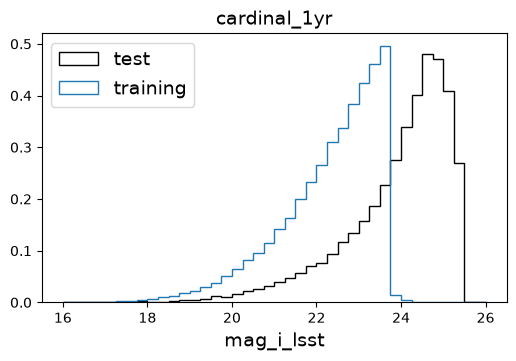

I0000 00:00:1791448755.026053 1659519 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 79189 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:03:00.0, compute capability: 8.0
I0000 00:00:1791448755.029905 1659519 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 79189 MB memory:  -> device: 1, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:41:00.0, compute capability: 8.0
I0000 00:00:1791448755.036303 1659519 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:2 with 79189 MB memory:  -> device: 2, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:82:00.0, compute capability: 8.0
I0000 00:00:1791448755.040118 1659519 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:3 with 79189 MB memory:  -> device: 3, name: NVIDIA A100-SXM4-80GB, pci bus id: 0000:c1:00.0, compute capability: 8.0



--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791448758.431123 1659980 service.cc:153] XLA service 0x7f4ba4035340 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1791448758.431148 1659980 service.cc:161]   StreamExecutor [0]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791448758.431160 1659980 service.cc:161]   StreamExecutor [1]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791448758.431166 1659980 service.cc:161]   StreamExecutor [2]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791448758.431170 1659980 service.cc:161]   StreamExecutor [3]: NVIDIA A100-SXM4-80GB, Compute Capability 8.0 (Driver: 13.0.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.27.0)
I0000 00:00:1791448758.479334 1659980 dump_mlir_util.cc:269] disabling MLIR crash repro

250/250 - 20s - 80ms/step - loss: 0.0021 - val_loss: 8.3493e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0012 - val_loss: 7.7712e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 9.9450e-04 - val_loss: 7.2963e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 9.1916e-04 - val_loss: 6.5834e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 8.7291e-04 - val_loss: 7.0271e-04 - learning_rate: 0.0010
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 8.2779e-04 - val_loss: 6.4288e-04 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 7.5086e-04 - val_loss: 5.7490e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 6.9625e-04 - val_loss: 5.6438e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 6.8733e-04 - val_loss: 5.5895e-04 - learning_rate: 5.0000e-04
Epoch 10/10

I0000 00:00:1791448795.806466 1659980 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_32434__.37


...

250/250 - 5s - 19ms/step - loss: 0.0017 - val_loss: 8.7437e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0011 - val_loss: 8.5744e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 9.4755e-04 - val_loss: 7.3773e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 8.9665e-04 - val_loss: 7.0375e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 8.4791e-04 - val_loss: 7.7335e-04 - learning_rate: 0.0010
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 8.4410e-04 - val_loss: 7.1149e-04 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 7.3133e-04 - val_loss: 6.4834e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 7.1223e-04 - val_loss: 6.6844e-04 - learning_rate: 5.0000e-04
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - los

I0000 00:00:1791448827.438645 1659978 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_70900__.37


250/250 - 5s - 19ms/step - loss: 0.0020 - val_loss: 9.6800e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0012 - val_loss: 8.5734e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0010 - val_loss: 6.9146e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 8.9646e-04 - val_loss: 6.8131e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 8.5708e-04 - val_loss: 6.5337e-04 - learning_rate: 0.0010
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 8.4430e-04 - val_loss: 6.7206e-04 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 7.3019e-04 - val_loss: 6.0380e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 6.8391e-04 - val_loss: 5.8902e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 6.8726e-04 - val_loss: 5.7989e-04 - learning_rate: 5.0000e-04
Epoch 10/100
250

I0000 00:00:1791448849.283983 1659980 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_98453__.37


250/250 - 5s - 19ms/step - loss: 0.0020 - val_loss: 8.7291e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0012 - val_loss: 7.3400e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 9.6507e-04 - val_loss: 7.5684e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 8.7611e-04 - val_loss: 6.4382e-04 - learning_rate: 0.0010
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 8.5865e-04 - val_loss: 7.1161e-04 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 7.5968e-04 - val_loss: 5.9939e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 7.2884e-04 - val_loss: 5.8277e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 7.0282e-04 - val_loss: 5.6845e-04 - learning_rate: 5.0000e-04
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step -

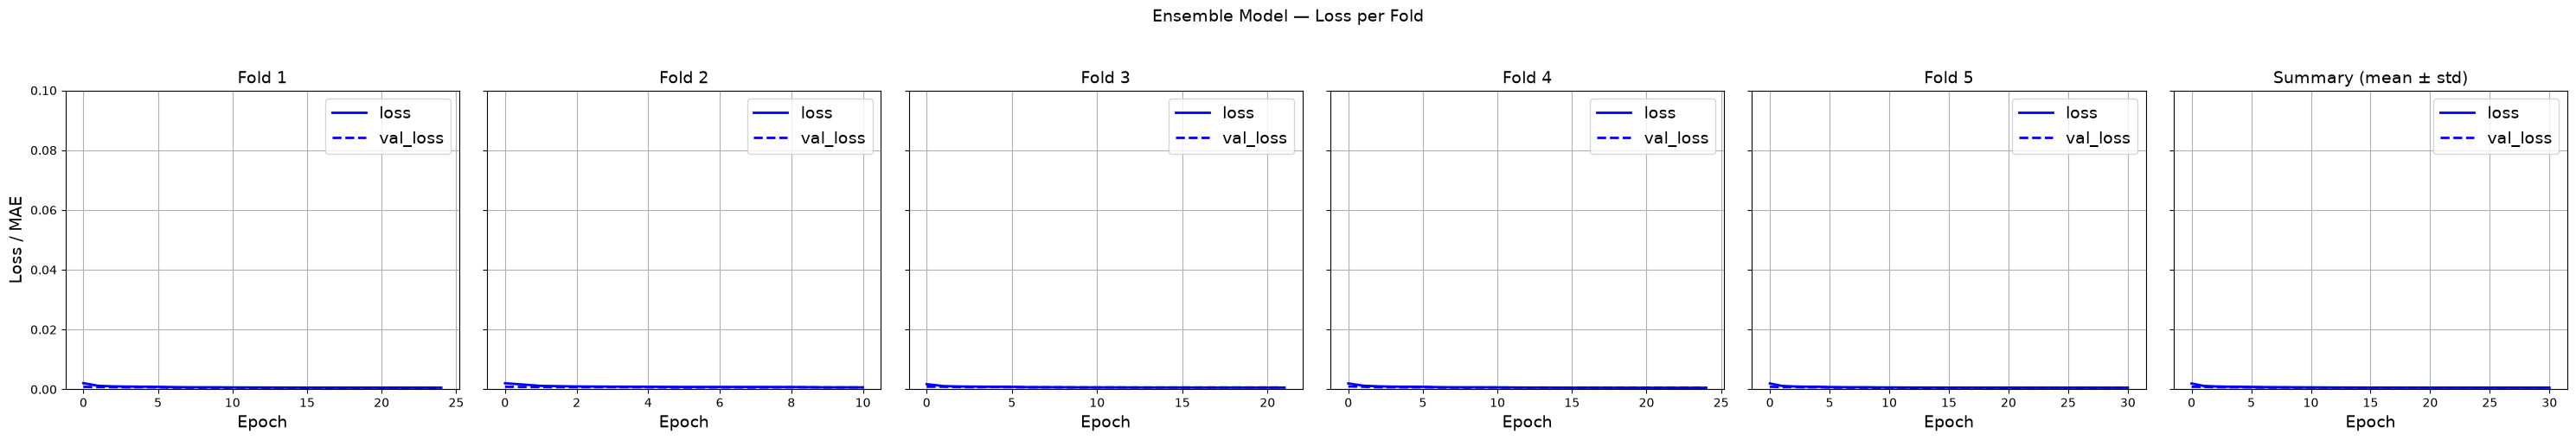

/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/znn/plotting.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


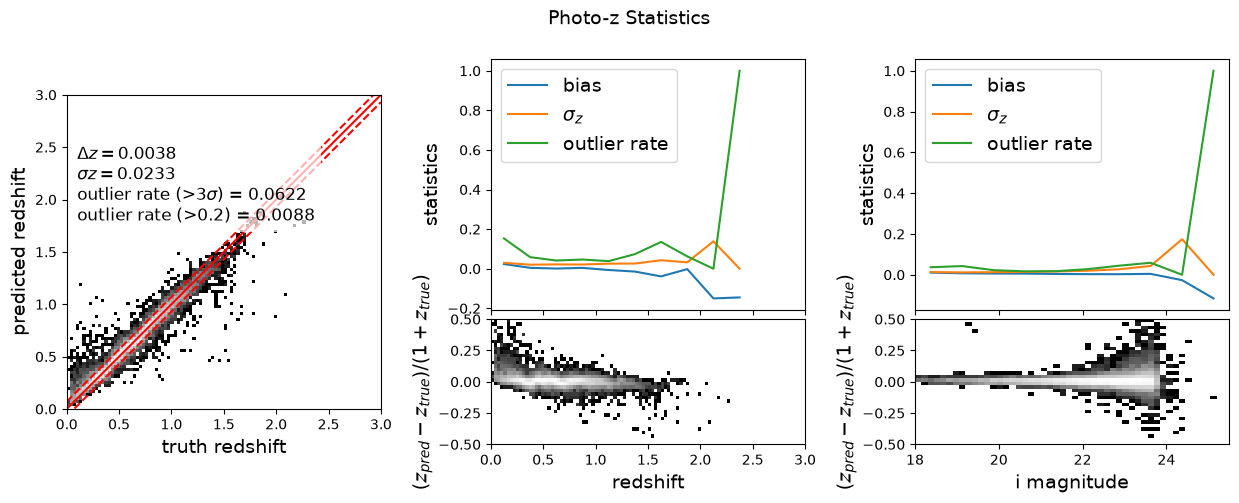

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/homes/j/jaimerz/envs/pzdc/lib/py

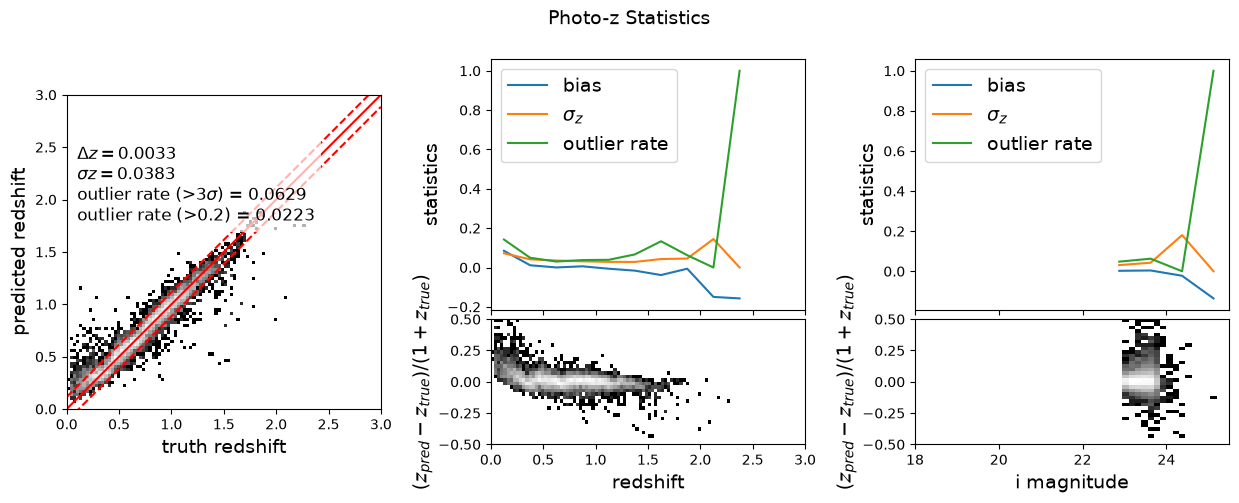

<Figure size 640x480 with 0 Axes>

/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/znn/data.py:157: RuntimeWarning: invalid value encountered in subtract
  mags_normed = mags - mag_i[None, :]  # normalize by i-band mag, per band, before binning


outputs/znn_pretrained_popcosmos/pz_challenge_taskset_2_cardinal_pz_estimate_1yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]

========== task set 2: cardinal_10yr ==========


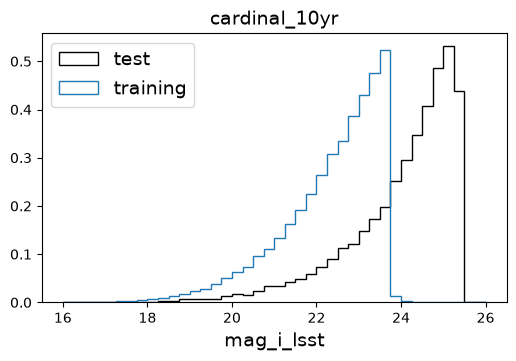


--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791449020.376469 1659975 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_203806__.37


250/250 - 5s - 19ms/step - loss: 0.0013 - val_loss: 2.7666e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 5.9903e-04 - val_loss: 2.8098e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 4.9379e-04 - val_loss: 2.8000e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 4.4828e-04 - val_loss: 2.1767e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 3.8182e-04 - val_loss: 1.9586e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 3.9198e-04 - val_loss: 1.6635e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 3.5455e-04 - val_loss: 1.5732e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.5339e-04 - val_loss: 1.5151e-04 - learning_rate: 5.0000e-04
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3m

I0000 00:00:1791449039.243717 1659980 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_227451__.37


250/250 - 5s - 19ms/step - loss: 0.0012 - val_loss: 3.4012e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 5.9289e-04 - val_loss: 2.4595e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 4.5191e-04 - val_loss: 3.0087e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 4.3230e-04 - val_loss: 2.1892e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 3.9018e-04 - val_loss: 1.9963e-04 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 3.8706e-04 - val_loss: 2.4006e-04 - learning_rate: 0.0010
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 4.0252e-04 - val_loss: 2.3828e-04 - learning_rate: 0.0010
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.7302e-04 - val_loss: 2.1606e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 3.5818e-04 - val_loss: 1.7740e-04 - learning_rate: 5.0000e-04
Epoch 10/100

...

250/250 - 5s - 19ms/step - loss: 0.0010 - val_loss: 3.6044e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 5.4339e-04 - val_loss: 3.0587e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 5.0223e-04 - val_loss: 2.2396e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 4.3118e-04 - val_loss: 1.5454e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 4.3798e-04 - val_loss: 2.0163e-04 - learning_rate: 0.0010
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 4.2806e-04 - val_loss: 2.0693e-04 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 3.9939e-04 - val_loss: 1.9736e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.7083e-04 - val_loss: 1.3772e-04 - learning_rate: 5.0000e-04
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step -

I0000 00:00:1791449084.579604 1659980 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_285443__.37


250/250 - 5s - 19ms/step - loss: 0.0012 - val_loss: 4.0511e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.3142e-04 - val_loss: 2.8259e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 4.6454e-04 - val_loss: 1.8401e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 4.1495e-04 - val_loss: 1.9920e-04 - learning_rate: 0.0010
Epoch 5/100

Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 3.7401e-04 - val_loss: 2.7100e-04 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 3.4334e-04 - val_loss: 1.6078e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 3.2546e-04 - val_loss: 1.5117e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.0715e-04 - val_loss: 1.5381e-04 - learning_rate: 5.0000e-04
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/st

I0000 00:00:1791449109.070128 1659979 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_316814__.37


250/250 - 5s - 18ms/step - loss: 0.0012 - val_loss: 2.6776e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 5.7630e-04 - val_loss: 2.3865e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 4.5329e-04 - val_loss: 2.0897e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 4.2662e-04 - val_loss: 2.0202e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 3.6790e-04 - val_loss: 1.6885e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 3.7240e-04 - val_loss: 1.5502e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 3.6651e-04 - val_loss: 1.3942e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 3.4870e-04 - val_loss: 1.4997e-04 - learning_rate: 5.0000e-04
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3m

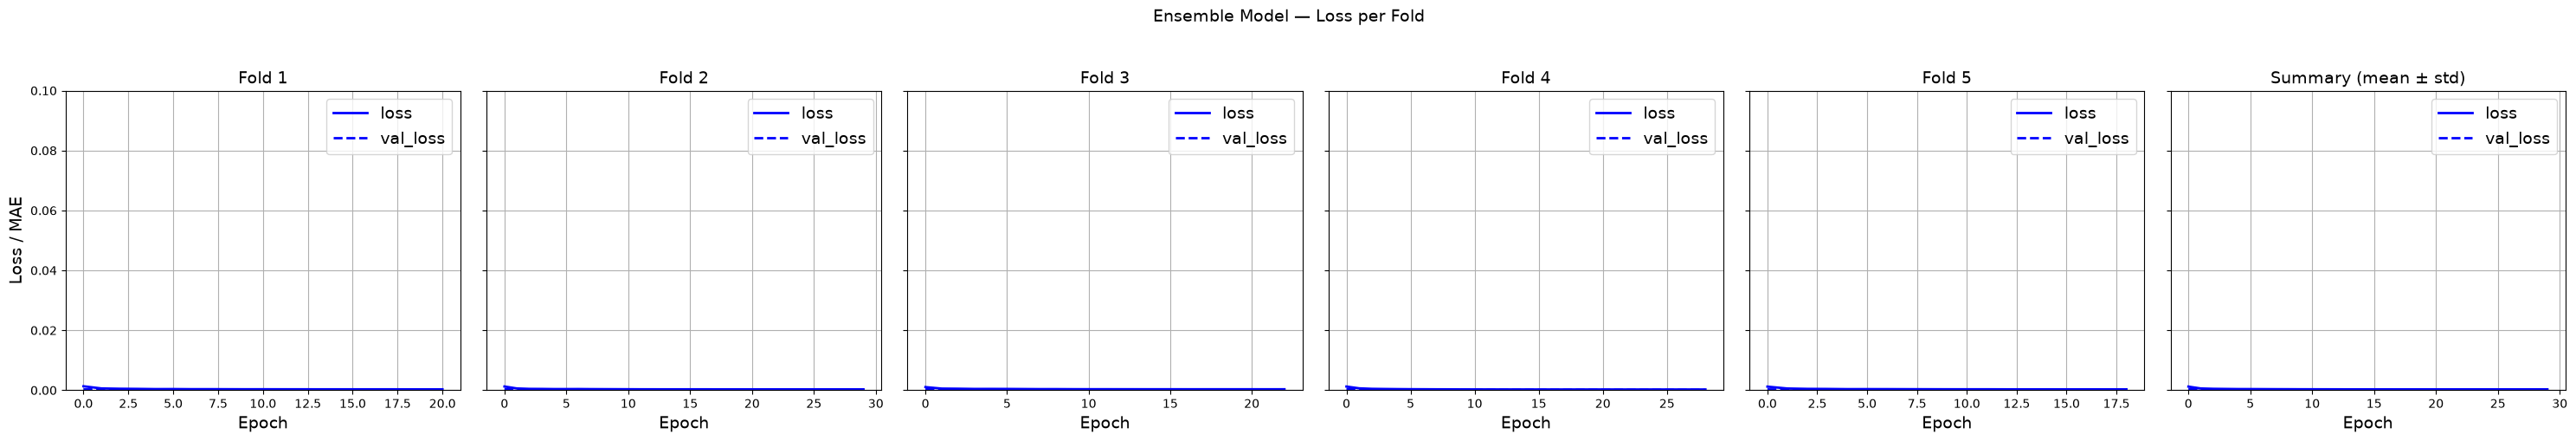

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset

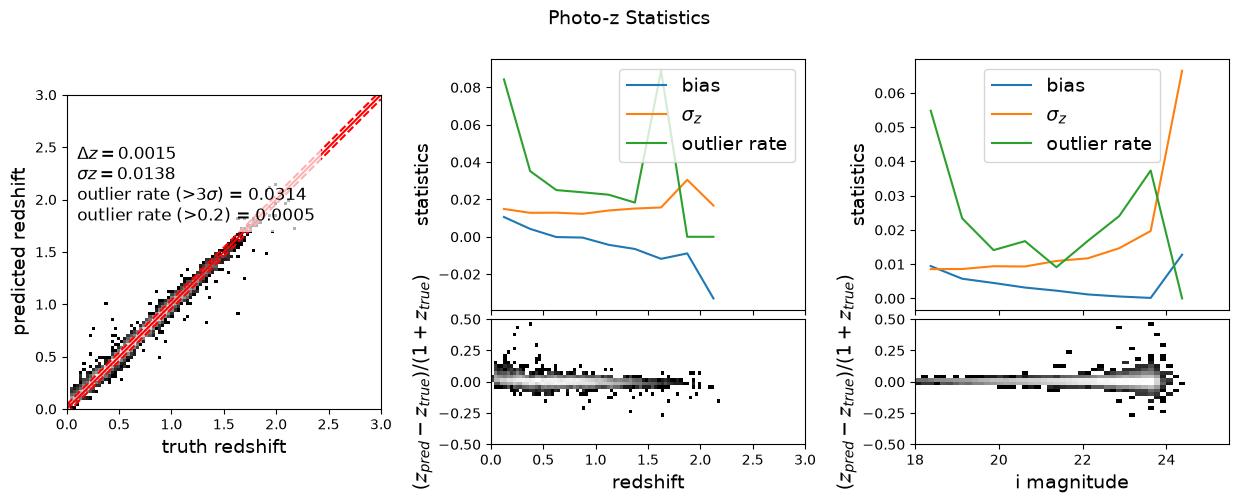

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)


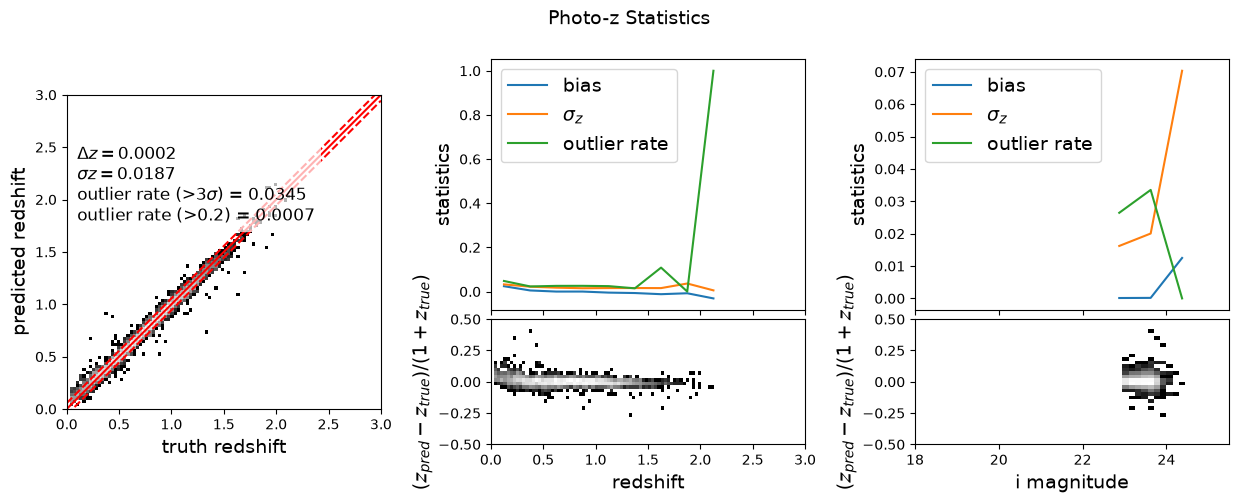

<Figure size 640x480 with 0 Axes>

outputs/znn_pretrained_popcosmos/pz_challenge_taskset_2_cardinal_pz_estimate_10yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]

========== task set 2: flagship_1yr ==========


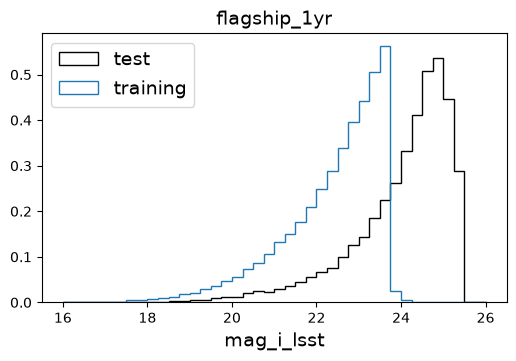


--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791449264.952908 1659980 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_410527__.37


250/250 - 5s - 19ms/step - loss: 0.0020 - val_loss: 8.2350e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0012 - val_loss: 7.0745e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0011 - val_loss: 6.6859e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0010 - val_loss: 6.6028e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 9.7462e-04 - val_loss: 5.8712e-04 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 9.7970e-04 - val_loss: 7.5393e-04 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 9.5715e-04 - val_loss: 6.1969e-04 - learning_rate: 0.0010
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 9.2540e-04 - val_loss: 5.8771e-04 - learning_rate: 0.0010
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 8.6331e-04 - val_loss: 5.1306e-04 - learning_rate: 5.0000e-04
Epoch 10/100
250/250 - 1s - 

I0000 00:00:1791449284.022652 1659980 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_434169__.37


250/250 - 5s - 19ms/step - loss: 0.0019 - val_loss: 7.5306e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0012 - val_loss: 7.1115e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0010 - val_loss: 5.9852e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 9.9887e-04 - val_loss: 5.6269e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 9.3629e-04 - val_loss: 5.2957e-04 - learning_rate: 0.0010
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 9.2361e-04 - val_loss: 6.0518e-04 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 8.7013e-04 - val_loss: 4.8942e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 8.6059e-04 - val_loss: 5.2616e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 8.5280e-04 - val_loss: 5.1441e-04 - learning_rate: 5.0000e-04
Epoch 10/100

Ep

...

250/250 - 5s - 18ms/step - loss: 0.0018 - val_loss: 8.3307e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0012 - val_loss: 7.1214e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0010 - val_loss: 6.2587e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0010 - val_loss: 5.6494e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 9.6769e-04 - val_loss: 5.9727e-04 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 9.4266e-04 - val_loss: 5.3472e-04 - learning_rate: 0.0010
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 9.4060e-04 - val_loss: 6.1044e-04 - learning_rate: 0.0010
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 8.7692e-04 - val_loss: 5.5940e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 8.6266e-04 - val_loss: 5.2086e-04 - learning_rate: 5.0000e-04
Epoch 10/100

Epoch 10: 

I0000 00:00:1791449330.770979 1659980 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_494185__.37


250/250 - 5s - 20ms/step - loss: 0.0018 - val_loss: 8.0062e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0012 - val_loss: 7.5260e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0010 - val_loss: 7.1547e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 9.2665e-04 - val_loss: 8.2377e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 8.4584e-04 - val_loss: 6.1089e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 8.1880e-04 - val_loss: 6.0163e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 8.0582e-04 - val_loss: 5.5642e-04 - learning_rate: 5.0000e-04
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 7.9797e-04 - val_loss: 5.8294e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step -

I0000 00:00:1791449353.554494 1659980 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_522673__.37


250/250 - 5s - 19ms/step - loss: 0.0019 - val_loss: 7.1448e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 0.0012 - val_loss: 6.1818e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 0.0011 - val_loss: 5.8348e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 0.0010 - val_loss: 5.5187e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 9.5422e-04 - val_loss: 5.7922e-04 - learning_rate: 0.0010
Epoch 6/100

Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 9.4280e-04 - val_loss: 5.3658e-04 - learning_rate: 0.0010
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 8.7554e-04 - val_loss: 5.0985e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 8.5268e-04 - val_loss: 4.8663e-04 - learning_rate: 5.0000e-04
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 8.361

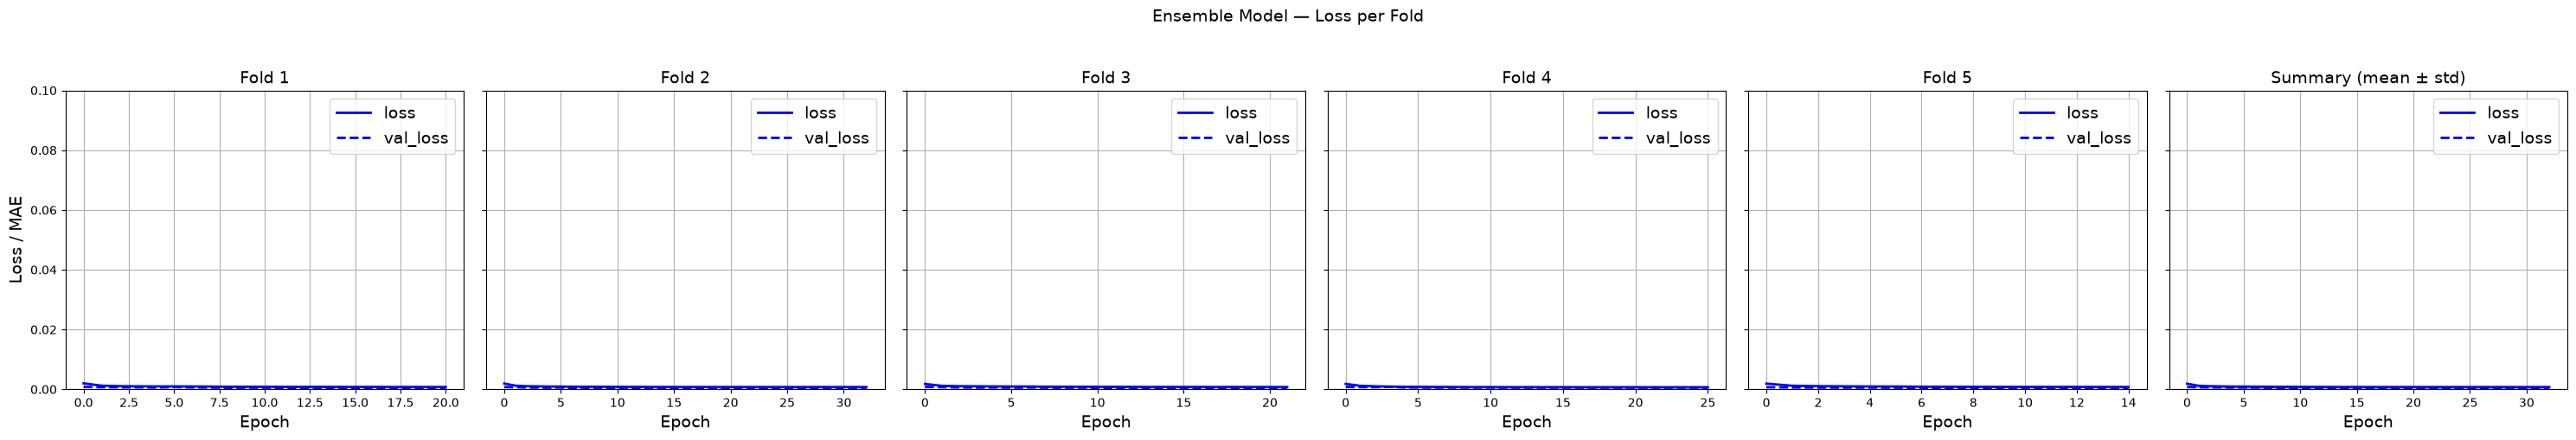

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset

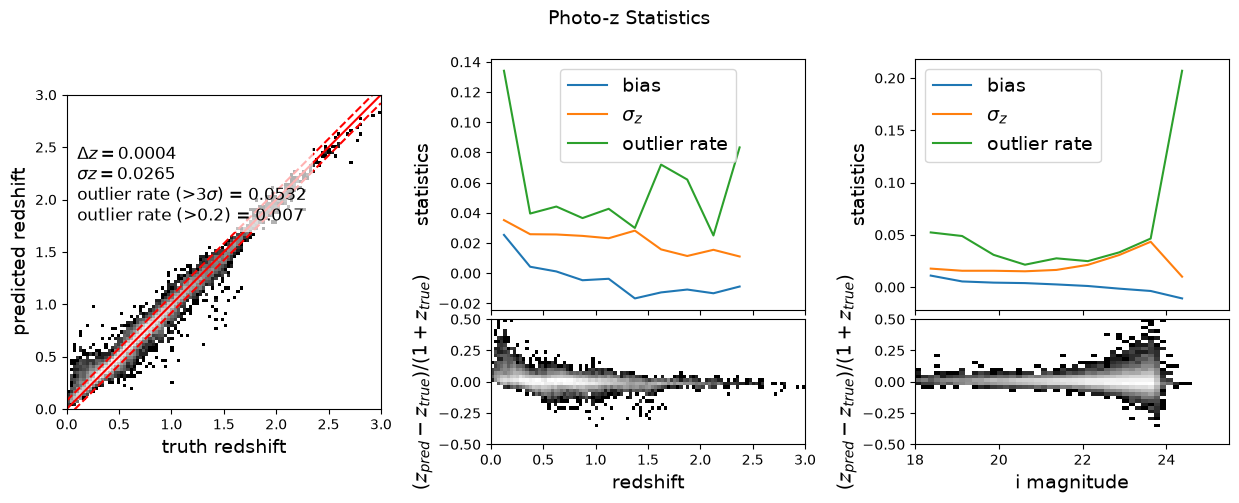

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
I0000 00:00:1791449423.762627 2312917 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 8 bytes spill stores, 8 bytes spill loads



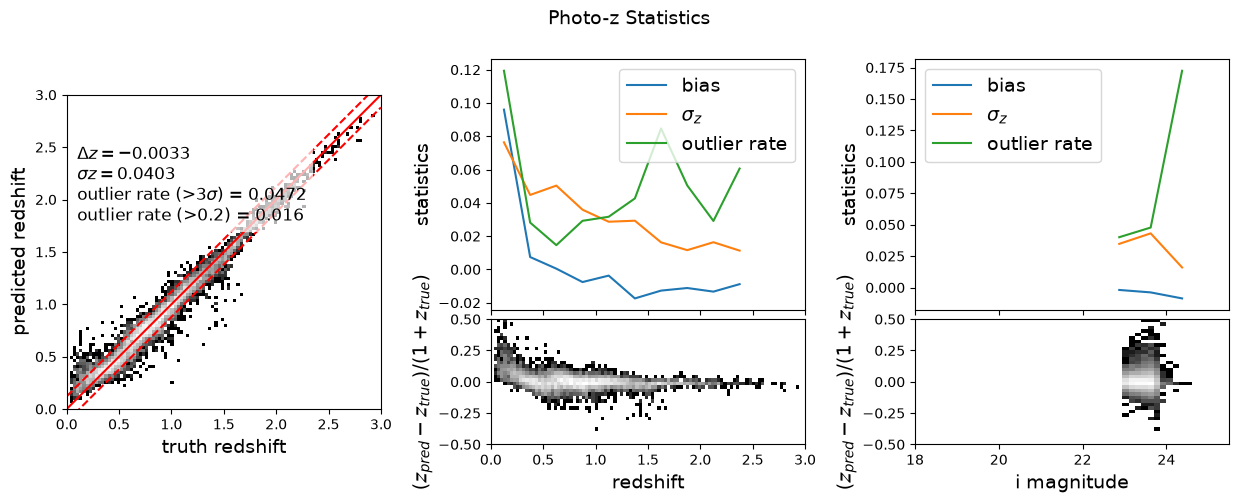

<Figure size 640x480 with 0 Axes>

/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset/znn/data.py:157: RuntimeWarning: invalid value encountered in subtract
  mags_normed = mags - mag_i[None, :]  # normalize by i-band mag, per band, before binning


outputs/znn_pretrained_popcosmos/pz_challenge_taskset_2_flagship_pz_estimate_1yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]

========== task set 2: flagship_10yr ==========


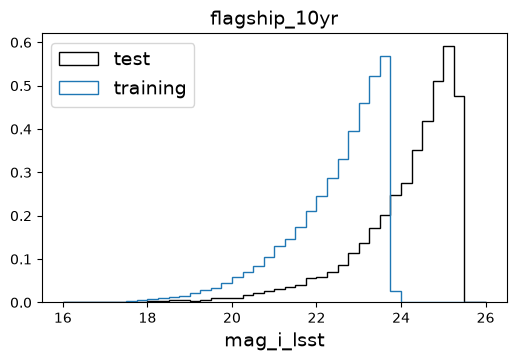


--- Fold 1/5 ---
Epoch 1/100


I0000 00:00:1791449507.986856 1659979 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_612504__.37


250/250 - 5s - 19ms/step - loss: 0.0012 - val_loss: 1.8377e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.7454e-04 - val_loss: 1.6820e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 5.9992e-04 - val_loss: 1.6301e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 5.8052e-04 - val_loss: 1.7591e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 5.5293e-04 - val_loss: 1.2009e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 5.3795e-04 - val_loss: 1.2603e-04 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 5.4355e-04 - val_loss: 1.2095e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 5.4702e-04 - val_loss: 1.1565e-04 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

I0000 00:00:1791449523.504080 1659977 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_631277__.37


250/250 - 5s - 19ms/step - loss: 0.0011 - val_loss: 1.9760e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.3194e-04 - val_loss: 1.4981e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 5.6416e-04 - val_loss: 1.5893e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 5.3784e-04 - val_loss: 1.3475e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 5.2419e-04 - val_loss: 1.4102e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 5.0245e-04 - val_loss: 1.3005e-04 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 5.0607e-04 - val_loss: 1.2429e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 4.9432e-04 - val_loss: 1.1195e-04 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

...

250/250 - 5s - 19ms/step - loss: 9.7103e-04 - val_loss: 2.4738e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.3147e-04 - val_loss: 1.7331e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 5.5640e-04 - val_loss: 1.8844e-04 - learning_rate: 0.0010
Epoch 4/100
250/250 - 1s - 3ms/step - loss: 5.5128e-04 - val_loss: 1.3899e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 5.5461e-04 - val_loss: 1.3086e-04 - learning_rate: 0.0010
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 5.3492e-04 - val_loss: 1.1386e-04 - learning_rate: 0.0010
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 5.2633e-04 - val_loss: 1.4187e-04 - learning_rate: 0.0010
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 5.0542e-04 - val_loss: 1.1323e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3ms/step - loss: 5.0222e-04 - val_loss: 1.0032e-04 - learning_rate: 5.0000e-04
Epoch 10

I0000 00:00:1791449571.733394 1659979 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_693125__.37


250/250 - 5s - 19ms/step - loss: 0.0011 - val_loss: 2.2050e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.1217e-04 - val_loss: 1.4021e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 4.9759e-04 - val_loss: 1.8877e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 4.7720e-04 - val_loss: 1.3367e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 4.4764e-04 - val_loss: 1.1739e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 4.5176e-04 - val_loss: 1.3463e-04 - learning_rate: 5.0000e-04
Epoch 7/100
250/250 - 1s - 3ms/step - loss: 4.3943e-04 - val_loss: 1.1415e-04 - learning_rate: 5.0000e-04
Epoch 8/100

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 4.3110e-04 - val_loss: 1.2851e-04 - learning_rate: 5.0000e-04
Epoch 9/100
250/250 - 1s - 3m

I0000 00:00:1791449588.099346 1659979 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_712859__.37


250/250 - 5s - 19ms/step - loss: 0.0011 - val_loss: 1.7378e-04 - learning_rate: 0.0010
Epoch 2/100
250/250 - 1s - 3ms/step - loss: 6.0573e-04 - val_loss: 1.7458e-04 - learning_rate: 0.0010
Epoch 3/100
250/250 - 1s - 3ms/step - loss: 5.4258e-04 - val_loss: 1.6567e-04 - learning_rate: 0.0010
Epoch 4/100

Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
250/250 - 1s - 3ms/step - loss: 5.4077e-04 - val_loss: 1.6345e-04 - learning_rate: 0.0010
Epoch 5/100
250/250 - 1s - 3ms/step - loss: 5.1151e-04 - val_loss: 1.2397e-04 - learning_rate: 5.0000e-04
Epoch 6/100
250/250 - 1s - 3ms/step - loss: 5.0623e-04 - val_loss: 1.4015e-04 - learning_rate: 5.0000e-04
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
250/250 - 1s - 3ms/step - loss: 5.0432e-04 - val_loss: 1.4149e-04 - learning_rate: 5.0000e-04
Epoch 8/100
250/250 - 1s - 3ms/step - loss: 4.8300e-04 - val_loss: 1.1965e-04 - learning_rate: 2.5000e-04
Epoch 9/100
250/250 - 1s - 3m

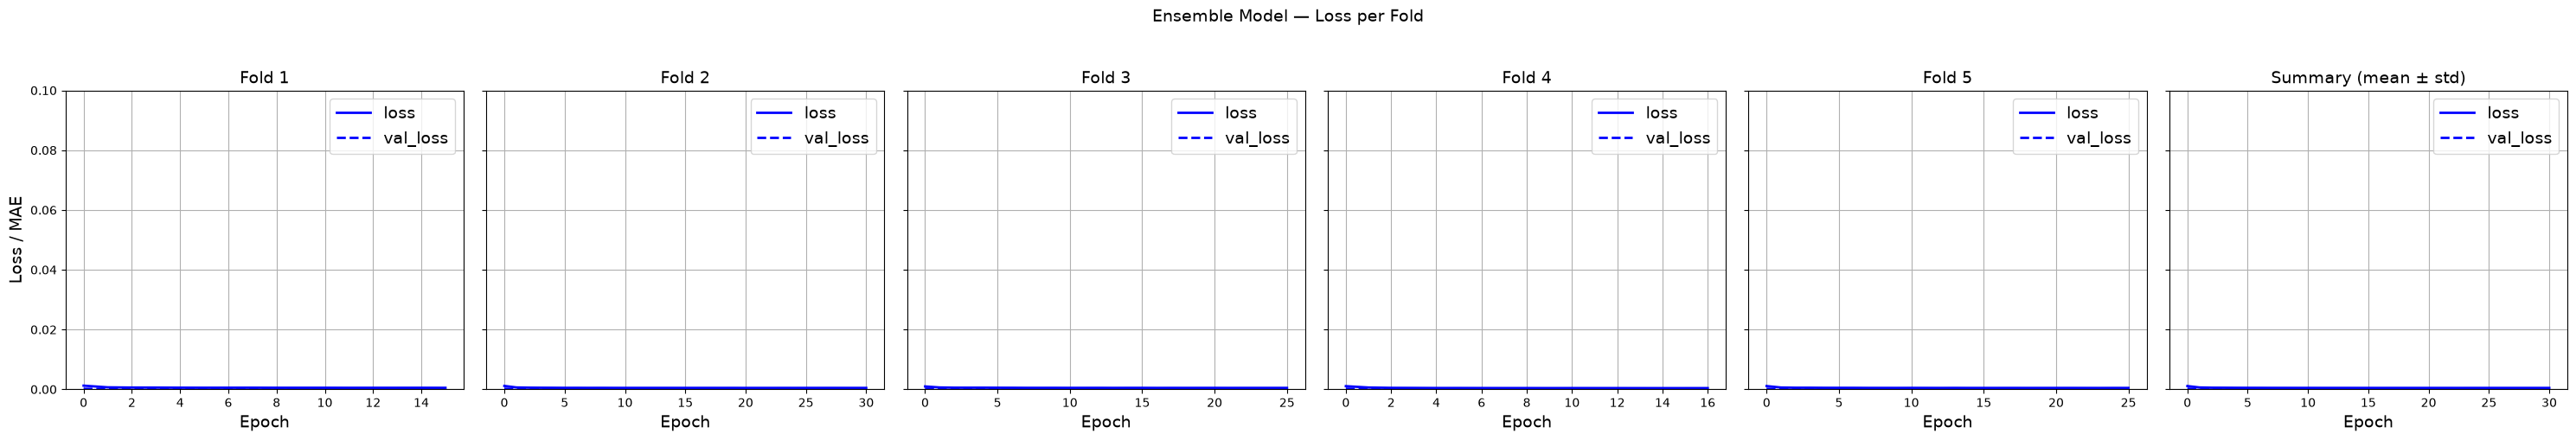

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:219: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:178: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:211: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:3862: RuntimeWarning: Mean of empty slice
  return _methods._mean(a, axis=axis, dtype=dtype,
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/numpy/_core/_methods.py:142: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/u2/j/jaimerz/UCL/mlpz_cnn_deepset

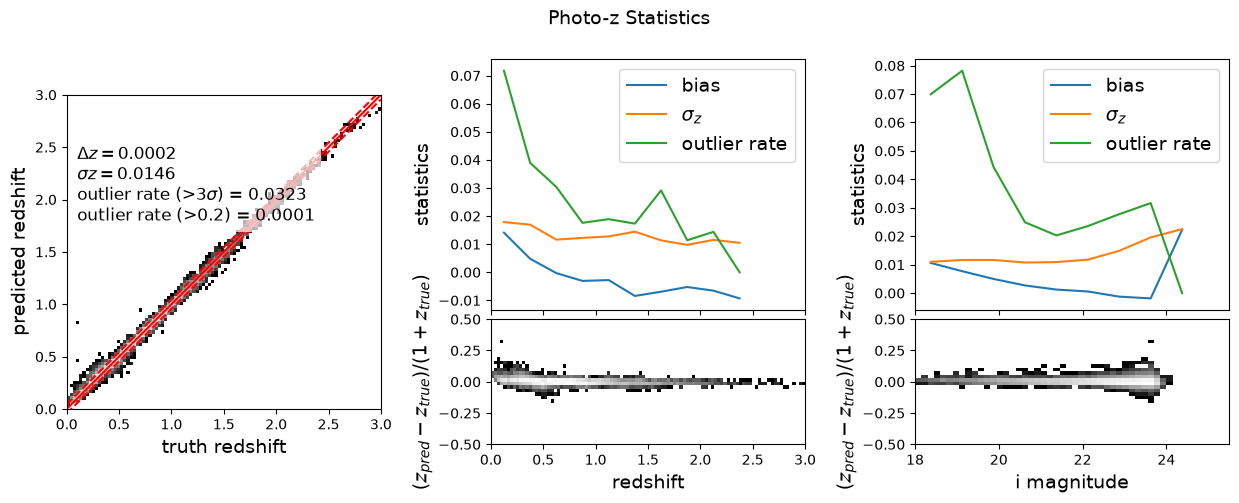

<Figure size 640x480 with 0 Axes>

/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: Parameter `variant` has been introduced to replace `midrank`; `midrank` will be removed in SciPy 1.19.0. Specify `variant` to silence this warning. Note that the returned object will no longer be unpackable as a tuple, and `critical_values` will be omitted.
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
/global/homes/j/jaimerz/envs/pzdc/lib/python3.12/site-packages/qp/metrics/array_metrics.py:27: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  return stats.anderson_ksamp([p_random_variables, q_random_variables], **kwargs)
I0000 00:00:1791449658.652266  214080 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_4', 8 bytes spill stores, 8 bytes spill loads



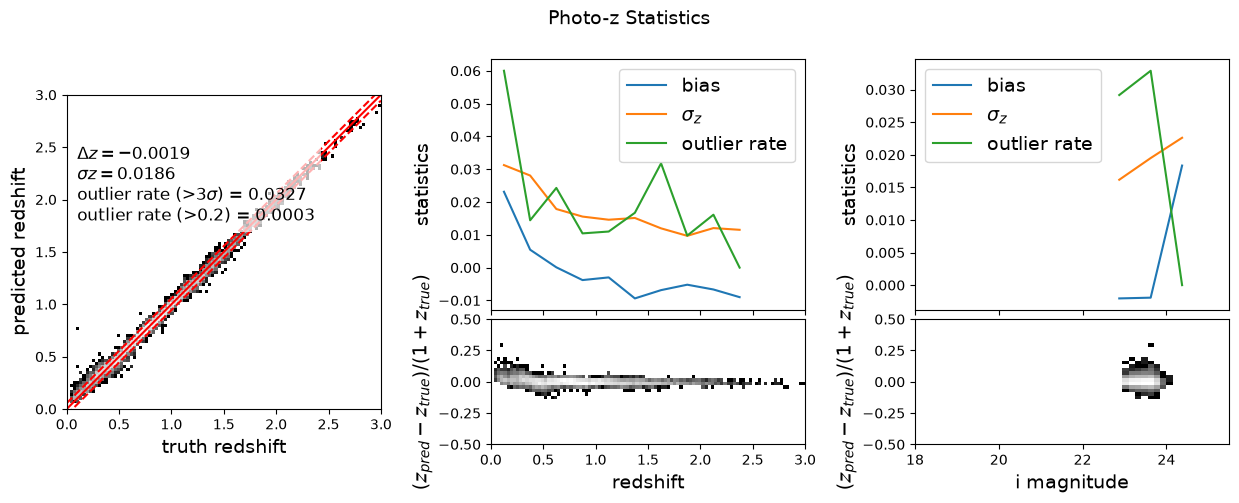

<Figure size 640x480 with 0 Axes>

outputs/znn_pretrained_popcosmos/pz_challenge_taskset_2_flagship_pz_estimate_10yr.hdf5 checks passed: [1, 2, 3, 4, 5, 6, 7]


In [5]:
results = {}

for SIM in SIMS:
    for SCENARIO in SCENARIOS:
        config = f"{SIM}_{SCENARIO}"
        print(f"\n========== task set {TASKSET}: {config} ==========")

        train_file = os.path.join(DATA_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_training_{SCENARIO}.hdf5")
        test_file = os.path.join(DATA_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_test_{SCENARIO}.hdf5")
        train = znn.read_catalog(train_file)
        test = znn.read_catalog(test_file)
        z_ref, subsets = reference_redshifts(train)

        # how representative is the training set of the test set?
        bins = np.linspace(16, 26, 41)
        plt.figure(figsize=[6, 3.5])
        plt.hist(test["mag_i_lsst"], bins, density=True, histtype="step", color="k", label="test")
        plt.hist(train["mag_i_lsst"], bins, density=True, histtype="step", label="training")
        plt.xlabel("mag_i_lsst")
        plt.title(config)
        plt.legend()
        plt.show()

        X, _ = znn.catalog_to_XY(train, BANDS, REF_BAND, FEATURE_CONFIG)
        rng = np.random.default_rng(NOISE_SEED)

        idx_fit, idx_val = train_test_split(np.arange(len(train)), test_size=VAL_FRAC, random_state=SEED)
        trained_models, histories = znn.train_ensembles(
            znn.build_model, X[idx_fit], z_ref[idx_fit], N_SPLITS=N_SPLITS, EPOCHS=EPOCHS, random_state=SEED, pretraining=PRETRAINING
        )
        znn.plot_ensemble_losses(histories, ylim=(0, 0.1))

        val = train.iloc[idx_val]
        for name, mask in subsets.items():
            m = mask[idx_val]
            results[(config, name)] = evaluate(
                trained_models, val[m], z_ref[idx_val][m], rng, title=f"{config}: {name}"
            )

        # submission files: subtask 1 p(z) and subtask 2 model
        estimate_file = os.path.join(OUT_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_pz_estimate_{SCENARIO}.hdf5")
        model_file = os.path.join(OUT_DIR, f"pz_challenge_taskset_{TASKSET}_{SIM}_pz_model_{SCENARIO}.pkl")

        pz_test = predict(trained_models, test, rng)
        pz_test.write_to(estimate_file)
        znn.save_ensemble_file(model_file, trained_models, BANDS, REF_BAND, FEATURE_CONFIG)

        checks = submit_utils.check_pz_submission_file(estimate_file, test_file)
        print(estimate_file, "checks passed:", checks)
        assert checks == [1, 2, 3, 4, 5, 6, 7], "submission file failed the challenge format checks"

## Summary

Metric values and points against the challenge scoring tiers (`pz_data_challenge.scoring.metric_dict`: three nested ranges per metric, one point per range), per configuration and held-out subset.

In [6]:
table = pd.DataFrame(results).T
table.index.names = ["configuration", "subset"]

points = pd.DataFrame({key: tier_points(values) for key, values in results.items()}).T
points["total"] = points.sum(axis=1)
points.index.names = ["configuration", "subset"]
n_max = sum(len(r) for r in scoring.metric_dict.values())

print("metric values")
print(table.round(4).to_string())
print(f"\npoints (out of 3 per metric, {n_max} in total)")
print(points.to_string())

metric values
                                                      mean     std  abs_outlier_rate      ks      CvM     ksamp  outlier  pit_outlier_direct
configuration subset                                                                                                                        
cardinal_1yr  held-out (spec-selected)              0.0038  0.0233            0.0088  0.1001  94.1080  358.6259   0.0101              0.0100
              held-out i > 23 (faintest available)  0.0033  0.0383            0.0223  0.0569   8.4687   28.8964   0.0011              0.0041
cardinal_10yr held-out (spec-selected)              0.0015  0.0138            0.0005  0.0782  52.8723  241.1759   0.0033              0.0098
              held-out i > 23 (faintest available)  0.0002  0.0187            0.0007  0.0296   2.6338   16.9122   0.0012              0.0051
flagship_1yr  held-out (spec-selected)              0.0004  0.0265            0.0070  0.0773  50.1886  289.7203   0.0180              0.0169